# 02 — Team EDA
Win rates, toss analysis, head-to-head, season trends

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['figure.facecolor'] = '#16213e'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#444'
ACCENT = '#f5a623'
PALETTE = ['#f5a623','#e74c3c','#3498db','#2ecc71','#9b59b6','#1abc9c','#e67e22','#e91e63']

matches = pd.read_csv('../data/processed/matches_clean.csv')
print(f'Loaded {len(matches)} matches')

Loaded 1095 matches


## 1. Overall Win Count — All Teams

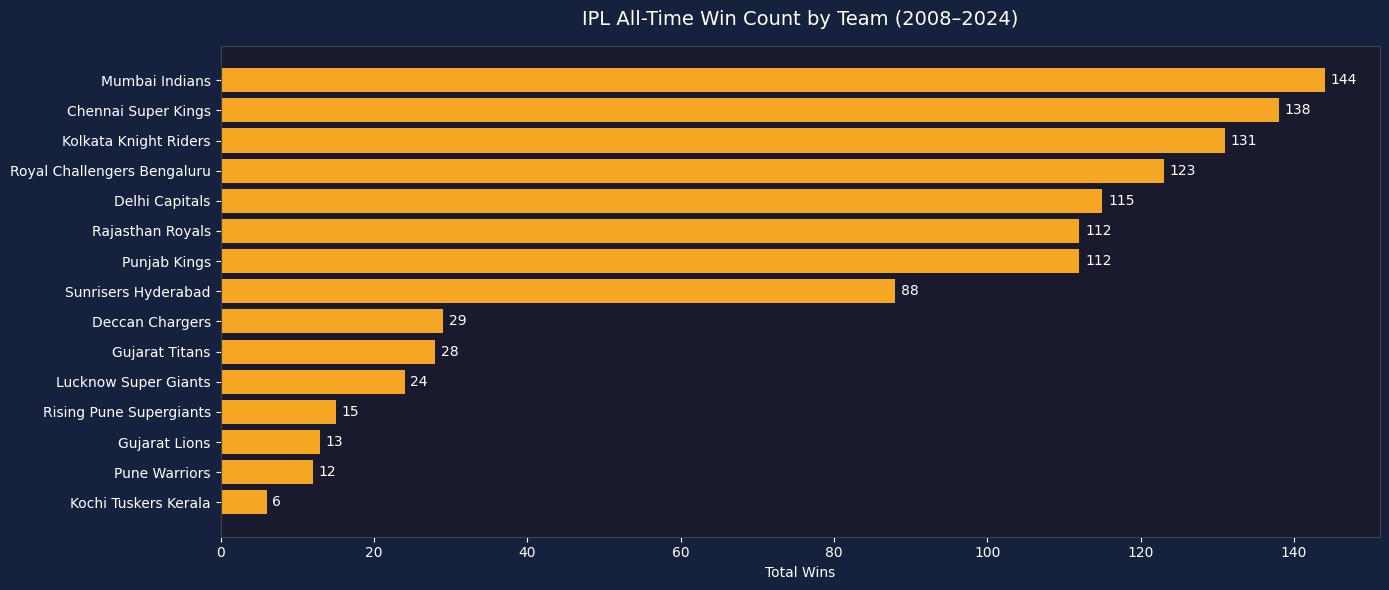

                           team  wins
0                Mumbai Indians   144
1           Chennai Super Kings   138
2         Kolkata Knight Riders   131
3   Royal Challengers Bengaluru   123
4                Delhi Capitals   115
5              Rajasthan Royals   112
6                  Punjab Kings   112
7           Sunrisers Hyderabad    88
8               Deccan Chargers    29
9                Gujarat Titans    28
10         Lucknow Super Giants    24
11      Rising Pune Supergiants    15
12                Gujarat Lions    13
13                Pune Warriors    12
14         Kochi Tuskers Kerala     6


In [2]:
win_counts = matches[matches['winner'] != 'No Result']['winner'].value_counts().reset_index()
win_counts.columns = ['team', 'wins']

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(win_counts['team'], win_counts['wins'], color=ACCENT, edgecolor='none')
ax.bar_label(bars, padding=4, color='white', fontsize=10)
ax.set_title('IPL All-Time Win Count by Team (2008–2024)', fontsize=14, pad=15)
ax.set_xlabel('Total Wins')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/01_win_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print(win_counts)

## 2. Win Rate (%) — Active Teams Only

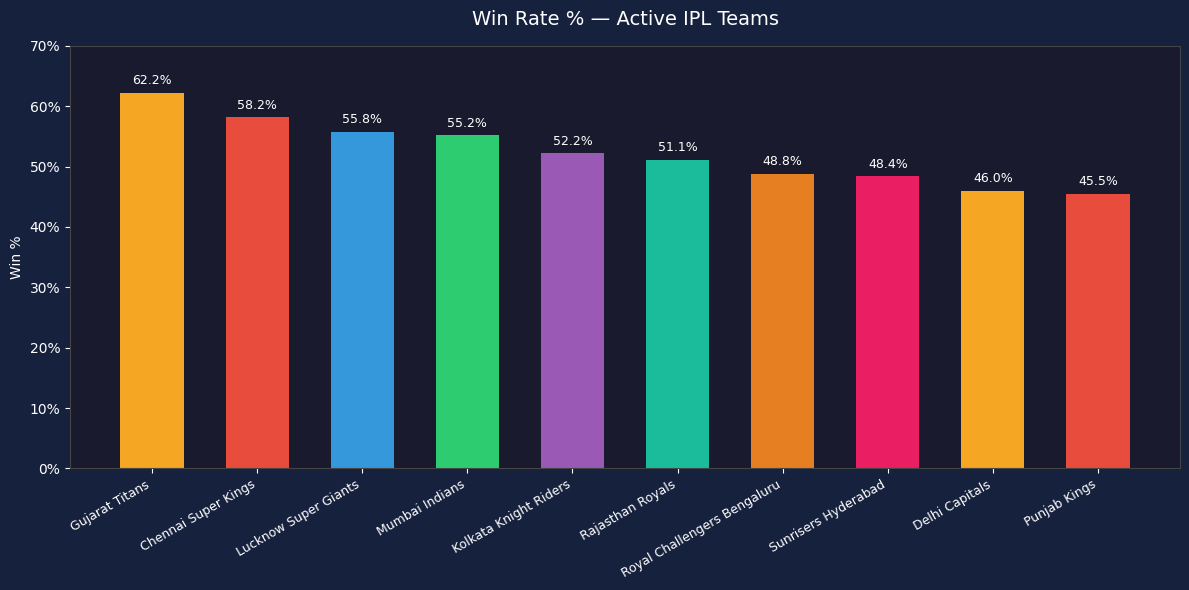

                       team  played  won  win_pct
             Gujarat Titans      45   28     62.2
        Chennai Super Kings     237  138     58.2
       Lucknow Super Giants      43   24     55.8
             Mumbai Indians     261  144     55.2
      Kolkata Knight Riders     251  131     52.2
           Rajasthan Royals     219  112     51.1
Royal Challengers Bengaluru     252  123     48.8
        Sunrisers Hyderabad     182   88     48.4
             Delhi Capitals     250  115     46.0
               Punjab Kings     246  112     45.5


In [3]:
active_teams = [
    'Mumbai Indians', 'Chennai Super Kings', 'Kolkata Knight Riders',
    'Royal Challengers Bengaluru', 'Delhi Capitals', 'Rajasthan Royals',
    'Punjab Kings', 'Sunrisers Hyderabad', 'Gujarat Titans', 'Lucknow Super Giants'
]

played = pd.concat([
    matches[matches['winner'] != 'No Result'][['team1','winner']].rename(columns={'team1':'team'}),
    matches[matches['winner'] != 'No Result'][['team2','winner']].rename(columns={'team2':'team'})
])
played['won'] = played['team'] == played['winner']
stats = played.groupby('team').agg(played=('won','count'), won=('won','sum')).reset_index()
stats['win_pct'] = (stats['won'] / stats['played'] * 100).round(1)
stats = stats[stats['team'].isin(active_teams)].sort_values('win_pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(stats['team'], stats['win_pct'], color=PALETTE[:len(stats)], edgecolor='none', width=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=4, color='white', fontsize=9)
ax.set_title('Win Rate % — Active IPL Teams', fontsize=14, pad=15)
ax.set_ylabel('Win %')
ax.set_ylim(0, 70)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('../assets/02_win_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print(stats[['team','played','won','win_pct']].to_string(index=False))

## 3. Toss Analysis — Does Winning the Toss Help?

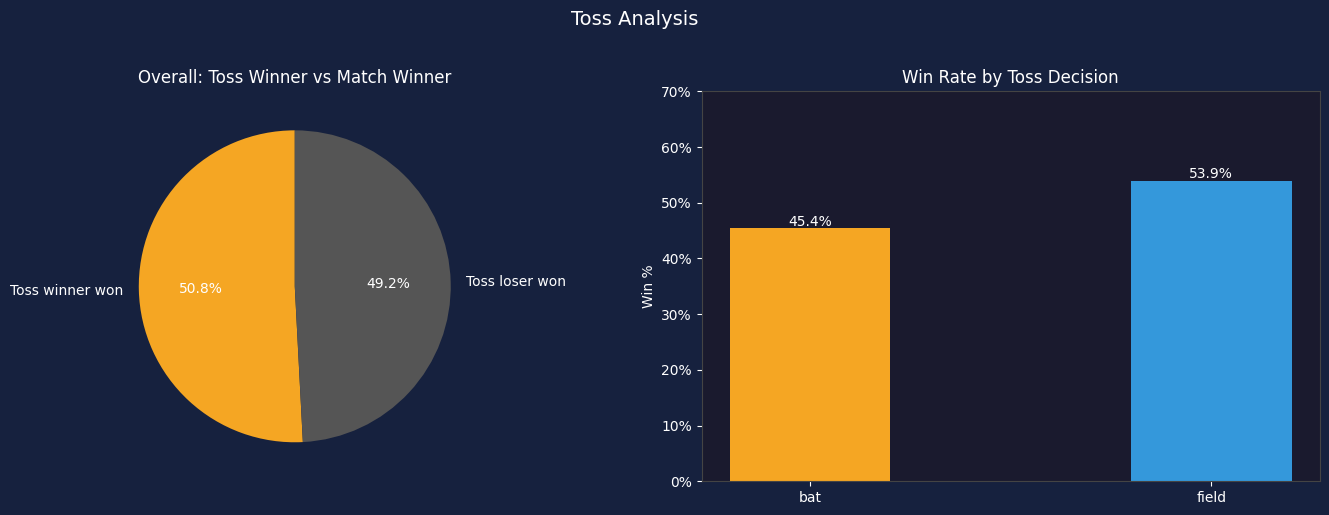

In [4]:
valid = matches[matches['winner'] != 'No Result']
toss_win_pct = valid['toss_winner_won'].mean() * 100

# Toss decision breakdown
toss_dec = valid.groupby('toss_decision')['toss_winner_won'].mean().reset_index()
toss_dec['win_pct'] = toss_dec['toss_winner_won'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie: overall toss winner win rate
axes[0].pie(
    [toss_win_pct, 100 - toss_win_pct],
    labels=['Toss winner won', 'Toss loser won'],
    colors=[ACCENT, '#555'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'color':'white'}
)
axes[0].set_title('Overall: Toss Winner vs Match Winner', fontsize=12)

# Bar: bat vs field decision
axes[1].bar(toss_dec['toss_decision'], toss_dec['win_pct'], color=[ACCENT, '#3498db'], width=0.4)
for i, row in toss_dec.iterrows():
    axes[1].text(i, row['win_pct'] + 0.5, f"{row['win_pct']:.1f}%", ha='center', color='white')
axes[1].set_title('Win Rate by Toss Decision', fontsize=12)
axes[1].set_ylabel('Win %')
axes[1].set_ylim(0, 70)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Toss Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../assets/03_toss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Season-wise Win Count — Top 5 Teams

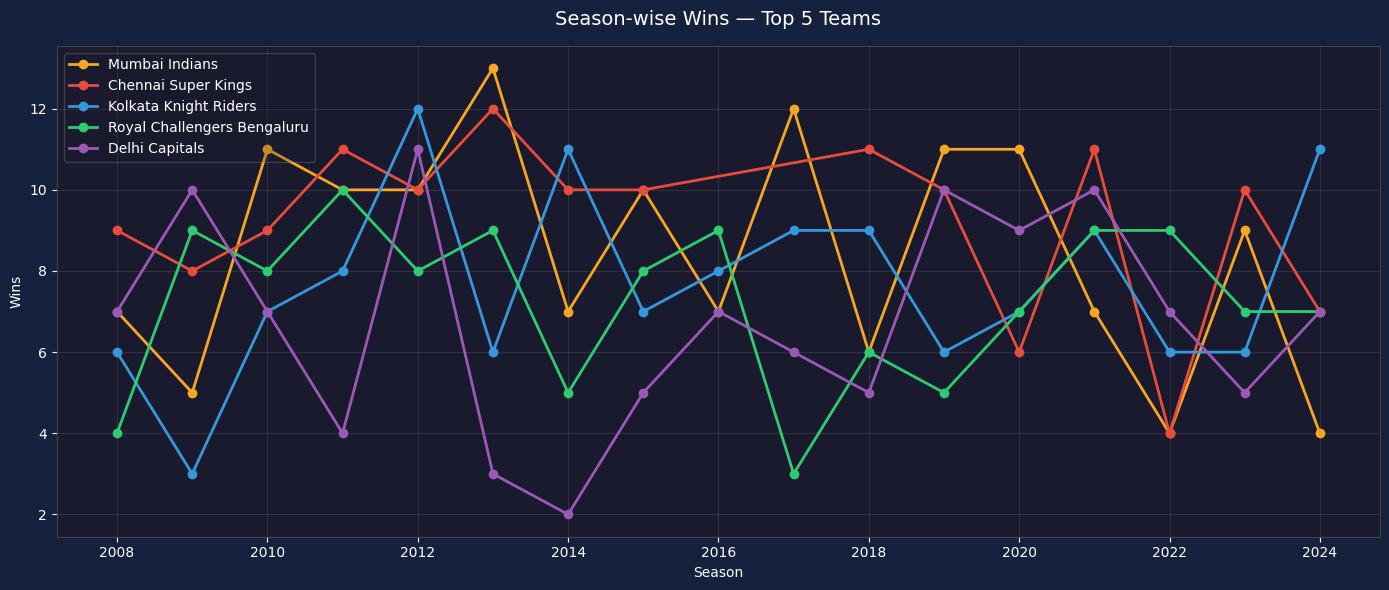

In [5]:
top5 = win_counts.head(5)['team'].tolist()
season_wins = valid[valid['winner'].isin(top5)].groupby(['season','winner']).size().reset_index(name='wins')

fig, ax = plt.subplots(figsize=(14, 6))
for i, team in enumerate(top5):
    d = season_wins[season_wins['winner'] == team]
    ax.plot(d['season'], d['wins'], marker='o', label=team, color=PALETTE[i], linewidth=2, markersize=6)

ax.set_title('Season-wise Wins — Top 5 Teams', fontsize=14, pad=15)
ax.set_xlabel('Season')
ax.set_ylabel('Wins')
ax.legend(loc='upper left', framealpha=0.2)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig('../assets/04_season_wins.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Head-to-Head Matrix — Top 8 Teams

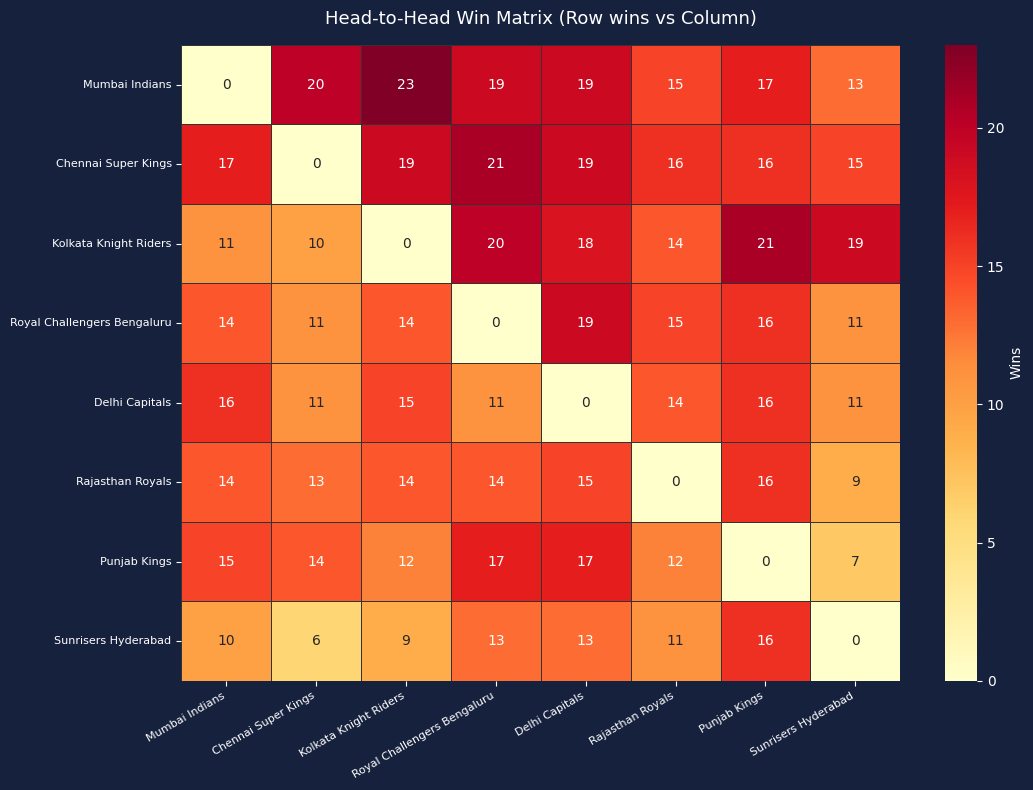

In [6]:
top8 = win_counts.head(8)['team'].tolist()
h2h = pd.DataFrame(0, index=top8, columns=top8)

for _, row in valid.iterrows():
    if row['team1'] in top8 and row['team2'] in top8 and row['winner'] in top8:
        h2h.loc[row['winner'], row['team1'] if row['winner'] == row['team2'] else row['team2']] += 1

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    h2h, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, linecolor='#333',
    ax=ax, cbar_kws={'label': 'Wins'}
)
ax.set_title('Head-to-Head Win Matrix (Row wins vs Column)', fontsize=13, pad=15)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../assets/05_h2h_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Bat First vs Chase Win Rate

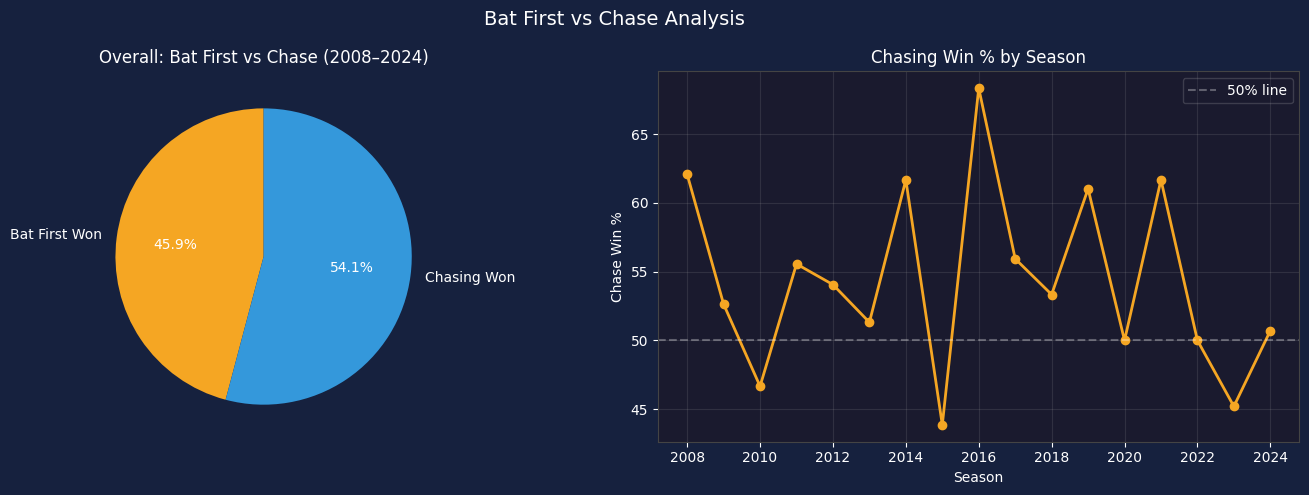

Bat first wins: 45.9% | Chasing wins: 54.1%


In [7]:
valid2 = valid.copy()
# team that batted first = team1 if toss_decision=field (team2 chose field so team1 bats), else team2 bats second
valid2['bat_first'] = valid2.apply(
    lambda r: r['team1'] if r['toss_winner'] == r['team2'] and r['toss_decision'] == 'field'
    else (r['team2'] if r['toss_winner'] == r['team1'] and r['toss_decision'] == 'field'
    else (r['team1'] if r['toss_decision'] == 'bat' and r['toss_winner'] == r['team1']
    else r['team2'])), axis=1
)
valid2['defending_won'] = valid2['bat_first'] == valid2['winner']
def_pct = valid2['defending_won'].mean() * 100
chase_pct = 100 - def_pct

# By season
season_chase = valid2.groupby('season')['defending_won'].apply(lambda x: (1 - x.mean()) * 100).reset_index()
season_chase.columns = ['season', 'chase_win_pct']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(
    [def_pct, chase_pct],
    labels=['Bat First Won', 'Chasing Won'],
    colors=[ACCENT, '#3498db'],
    autopct='%1.1f%%', startangle=90,
    textprops={'color': 'white'}
)
axes[0].set_title('Overall: Bat First vs Chase (2008–2024)')

axes[1].plot(season_chase['season'], season_chase['chase_win_pct'], color=ACCENT, marker='o', linewidth=2)
axes[1].axhline(50, color='white', linestyle='--', alpha=0.3, label='50% line')
axes[1].set_title('Chasing Win % by Season')
axes[1].set_ylabel('Chase Win %')
axes[1].set_xlabel('Season')
axes[1].legend(framealpha=0.2)
axes[1].grid(alpha=0.15)
plt.suptitle('Bat First vs Chase Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('../assets/06_bat_chase.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Bat first wins: {def_pct:.1f}% | Chasing wins: {chase_pct:.1f}%')

## 7. Export Team Summary for Power BI

In [8]:
# Full team stats table
all_played = pd.concat([
    matches[matches['winner'] != 'No Result'][['season','team1','winner']].rename(columns={'team1':'team'}),
    matches[matches['winner'] != 'No Result'][['season','team2','winner']].rename(columns={'team2':'team'})
])
all_played['won'] = all_played['team'] == all_played['winner']
team_summary = all_played.groupby(['team','season']).agg(
    played=('won','count'),
    won=('won','sum')
).reset_index()
team_summary['lost'] = team_summary['played'] - team_summary['won']
team_summary['win_pct'] = (team_summary['won'] / team_summary['played'] * 100).round(1)

team_summary.to_csv('../data/processed/team_season_summary.csv', index=False)
print('Saved team_season_summary.csv')
print(team_summary.head(10))

Saved team_season_summary.csv
                  team  season  played  won  lost  win_pct
0  Chennai Super Kings    2008      16    9     7     56.2
1  Chennai Super Kings    2009      14    8     6     57.1
2  Chennai Super Kings    2010      16    9     7     56.2
3  Chennai Super Kings    2011      16   11     5     68.8
4  Chennai Super Kings    2012      18   10     8     55.6
5  Chennai Super Kings    2013      18   12     6     66.7
6  Chennai Super Kings    2014      16   10     6     62.5
7  Chennai Super Kings    2015      17   10     7     58.8
8  Chennai Super Kings    2018      16   11     5     68.8
9  Chennai Super Kings    2019      17   10     7     58.8
